valid lines [4, 7, 6, 5, 0, 1, 2, 12, 11, 8, 13]


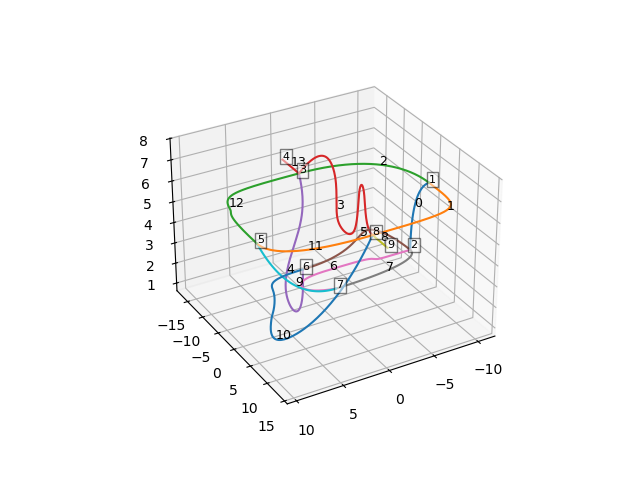

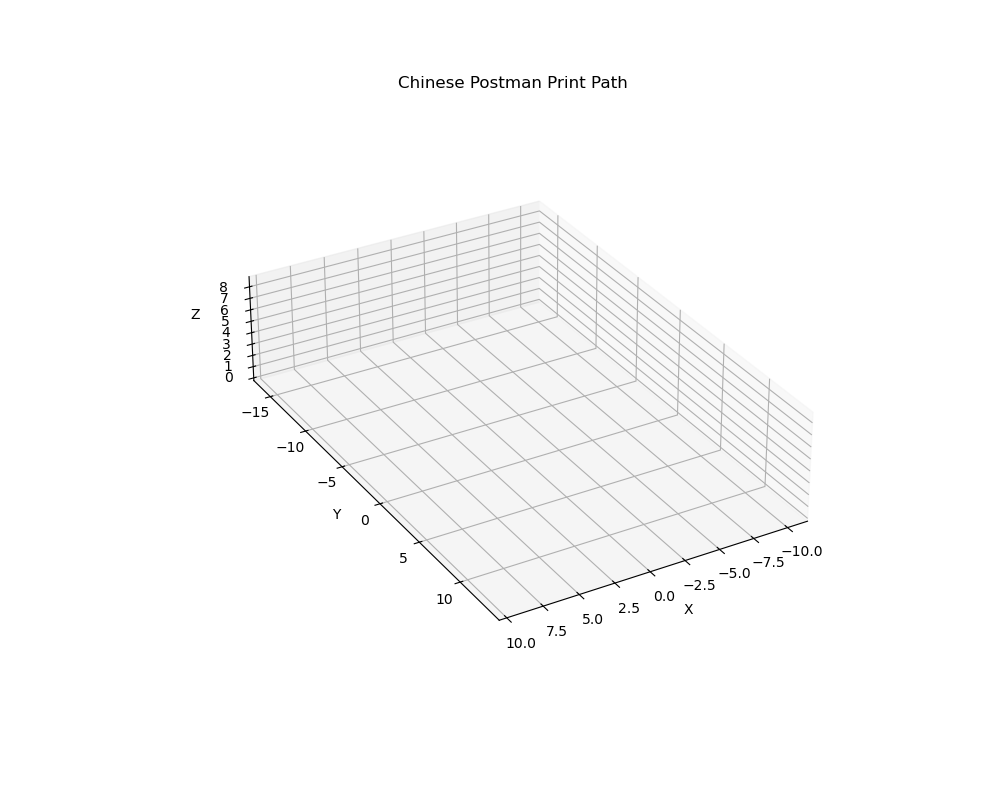

In [ ]:
%matplotlib widget

from fracprint import processor_open_chinese_postman as processor
from fracprint import writer_open_chinese_postman as writer

# File settings
filedir  = "./Rhino/"
filename = "newvesselbranched.txt"
fileout  = "postman.gcode"

# Base print settings
d = 0.8
x_offset, y_offset = 0, 0
bed_temperature = 0
floor = -26
z_min = -27
roof = 0
f_print = 200
E_clean = 10

# Extra behaviour settings
# Keep only keys that are safe to pass through settings.update(...)
extra_settings = {
    "split_graph_intersections": True,
    "graph_intersection_xy_tol": 1e-3,
    "graph_near_intersection_xy_tol": 0.1,
    "graph_intersection_z_tol": 0.05,
    "graph_node_tol": 0.25,
    "node_tol": 0.05,
    "node_nudge_mm": 3.0,
    "node_nudge_npts": 5,
    "node_slow_dist_mm": 0,
    "f_node": f_print,
    "slow_revisit_start": False,
}

# Build settings
settings = processor.build_settings(
    filedir, filename, fileout,
    d, x_offset, y_offset,
    bed_temperature, floor, z_min, roof,
    f_print, E_clean
)

settings.update(extra_settings)

# Preprocess geometry
df, line_order_grouped = processor.shape_prep(settings)

# Write gcode
df_print = writer.gcode_writer(df, settings, line_order_grouped)

# Animation
ani = processor.animate_postman_path(df, line_order_grouped)